<h1 style="color:Brown">Feature Engineering</h1>

In [183]:
import pandas as pd                    # data handling using DataFrames
import numpy as np                     # linear algebra, numerical operations (arrays, math)
import matplotlib.pyplot as pyplot     #  basic plotting
import seaborn as sns                  #  advanced & attractive statistical plots

In [184]:
df = pd.read_csv("Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [185]:
# iloc in pandas (Index-based Selection)

#  df.iloc[1:4, 0:2]          #  Rows 1–3 and columns 0–1
#         rows  columns     (range)
# Indexing starts from 0
# Slices (start:stop:step)

df = df.iloc[:,2:]          # store all rows and columns starting from index 2 to end
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


<h2 style="color:Blue">Train Test Split of DataFrame</h2>

In [186]:
from sklearn.model_selection import train_test_split        # Imports a function that splits data into training and testing sets for ML.
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),
                                                      df['Purchased'],
                                                      test_size=0.3,
                                                      random_state=0
                                                    )     
# df.drop('Purchased', axis=1)            # Removes the output column and keeps only input features (X)     (INPUT FEATURES)
# df['Purchased']                         # The target/output column (y) the model will predict             (EXPECTED OUTPUT COLUMN)
# test_size=0.3                           # 30% data for testing, 70% for training
# random_state=0                          # Ensures same data split every time (reproducibility)

# we can use above code with input(X) and output(y) like this:

# X = df.iloc[:, :-1]                 #  :-1 → all columns except last
# y = df.iloc[:, -1]                  #   -1 → only last column
# X_train, X_test, y_train, y_test = train_test_split(X, 
#                                                     y, 
#                                                     test_size=0.25, 
#                                                     random_state=0
#                                                    )

In [187]:
X_train.shape, X_test.shape

((280, 2), (120, 2))

<h2 style="color:Blue">StandardScaler</h2>

In [188]:
from sklearn.preprocessing import StandardScaler           # Used to standardize features
# Converts data to:            x - mean
#                         z = ----------
#                                std
scaler = StandardScaler()                    #  Creates a scaler instance

scaler.fit(X_train)       # fit the scaler to the train set, it will learn the parameters

# transform train and test sets
X_train_scaled = scaler.transform(X_train)          
X_test_scaled = scaler.transform(X_test)             # X_train_scaled and X_test_scaled have data in the form of **numpy array**

In [189]:
scaler.mean_               # mean of all input Featres in array form       (Age and EstimatedSalary)

array([3.78642857e+01, 6.98071429e+04])

In [190]:
# as X_train_scaled and X_test_scaled is in **numpy array** form, firstly convert them to dataframe
X_train_scaled = pd.DataFrame(X_train_scaled, columns= X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns= X_test.columns)

In [191]:
display(X_train.head(), X_train_scaled.head())

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000


,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047


In [192]:
np.round(X_train.describe(), decimals=2)    # np.round, rounds element of a NumPy array to a given number of decimals.

,Age,EstimatedSalary
count,280.00,280.00
mean,37.86,69807.14
std,10.22,34641.20
min,18.00,15000.00
25%,30.00,43000.00
50%,37.00,70500.00
75%,46.00,88000.00
max,60.00,150000.00


In [193]:
np.round(X_train_scaled.describe(), decimals=2)    # observe  Mean ≈ 0,   Standard deviation ≈ 1

,Age,EstimatedSalary
count,280.00,280.00
mean,0.00,0.00
std,1.00,1.00
min,-1.95,-1.58
25%,-0.77,-0.78
50%,-0.08,0.02
75%,0.80,0.53
max,2.17,2.32


<h2 style="color:Blue">Effect of Scaling</h2>

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

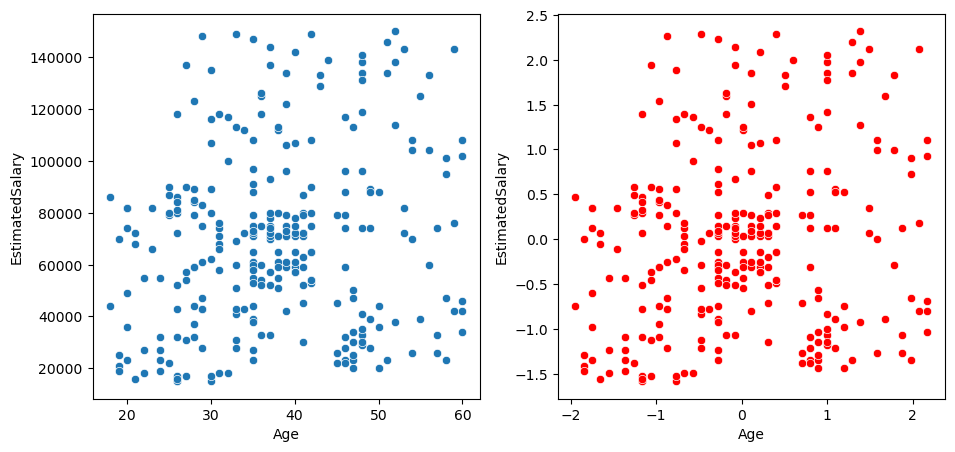

In [194]:
pyplot.figure(figsize=(11,5))
pyplot.subplot(1,2,1)
sns.scatterplot(x=X_train['Age'], y=X_train['EstimatedSalary'])        # KDE (Kernel Density Estimate) plot, it represents the data using a continuous probability density curve.

pyplot.subplot(1,2,2)
sns.scatterplot(x=X_train_scaled['Age'], y=X_train_scaled['EstimatedSalary'], color='red')

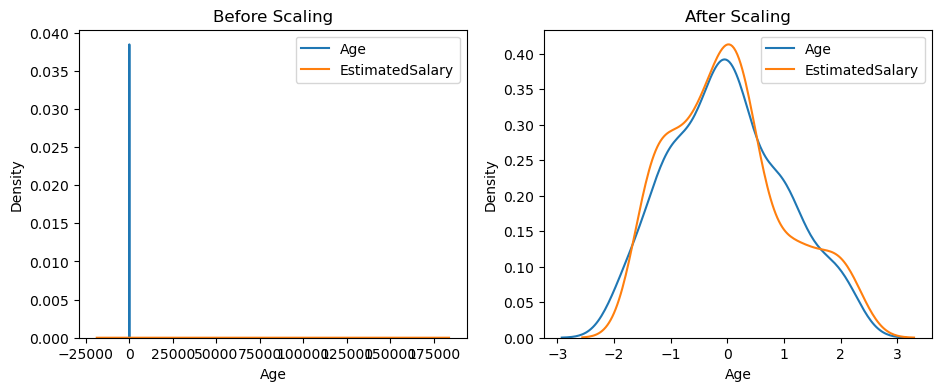

In [195]:
# KDE (Kernel Density Estimate) plot, it represents the data using a continuous probability density curve.
pyplot.figure(figsize=(11,4))
pyplot.subplot(1,2,1)
pyplot.title('Before Scaling')
# Age has a small range (approx 18–60), So its density is concentrated → looks tall / sharp
sns.kdeplot(X_train['Age'], label="Age")      
# EstimatedSalary has a very large range (15k–150k), Density is spread out → looks almost flat near x-axis
sns.kdeplot(X_train['EstimatedSalary'], label="EstimatedSalary")  
pyplot.legend()                                   #  give labels and call .legend()

pyplot.subplot(1,2,2)
pyplot.title('After Scaling')
sns.kdeplot(X_train_scaled['Age'], label="Age")
sns.kdeplot(X_train_scaled['EstimatedSalary'], label="EstimatedSalary")
pyplot.legend()


# ❗ Intuition:
# Because Age and Salary have VERY different scales, they cannot be compared properly on the same plot.
# This is why scaling is needed.
# as After standard scaling:
# mean becomes 0, standard deviation becomes 1,   Both features now lie in a similar range

<h2 style="color:Blue">Comparison of Individual Columns</h2>

<Axes: title={'center': 'Age Distribution After Scaling'}, xlabel='Age', ylabel='Density'>

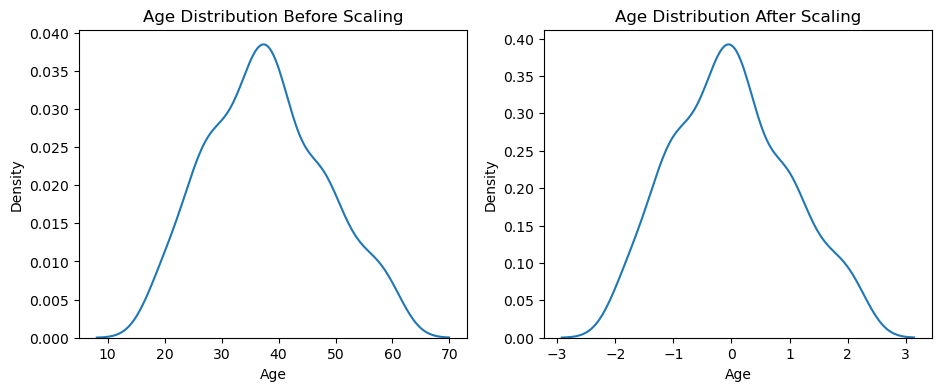

In [196]:
pyplot.figure(figsize=(11,4))
pyplot.subplot(1,2,1)
pyplot.title('Age Distribution Before Scaling')
sns.kdeplot(X_train['Age'])     

pyplot.subplot(1,2,2)
pyplot.title('Age Distribution After Scaling')
sns.kdeplot(X_train_scaled['Age'])

# ❗Intuition
# Shape of distribution stays same, Only the scale changes
# Standardization does NOT distort data

<Axes: title={'center': 'EstimatedSalary Distribution After Scaling'}, xlabel='EstimatedSalary', ylabel='Density'>

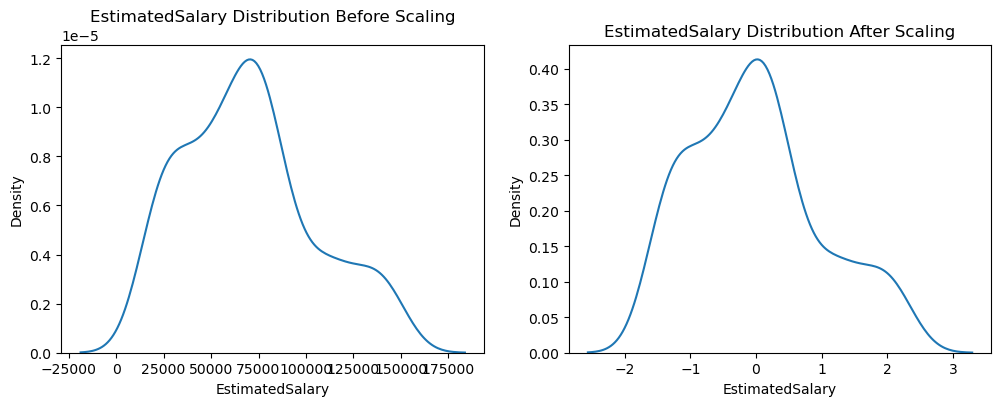

In [197]:
pyplot.figure(figsize=(12,4))
pyplot.subplot(1,2,1)
pyplot.title('EstimatedSalary Distribution Before Scaling')
sns.kdeplot(X_train['EstimatedSalary'])     

pyplot.subplot(1,2,2)
pyplot.title('EstimatedSalary Distribution After Scaling')
sns.kdeplot(X_train_scaled['EstimatedSalary'])

# ❗Intuition
# Shape of distribution stays same, Only the scale changes
# Standardization does NOT distort data

<h2 style="color:Blue">Why scaling is important?</h2>

<h4 style="color:red">Logistic Regression</h4>

In [198]:
from sklearn.linear_model import LogisticRegression

In [199]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [200]:
# Model learns patterns from training data
lr.fit(X_train, y_train)           # training algo the non-scaled data
lr_scaled.fit(X_train_scaled, y_train)  # training algo the scaled data

LogisticRegression()

In [201]:
# Predicts labels for test data
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [202]:
from sklearn.metrics import accuracy_score

In [203]:
print("actual Data Accuracy :", accuracy_score(y_test, y_pred))
print("Scaled Data Accuracy :", accuracy_score(y_test, y_pred_scaled))

actual Data Accuracy : 0.875
Scaled Data Accuracy : 0.8666666666666667


<h4 style="color:red">Decision Tree Classifier</h4>

In [204]:
from sklearn.tree import DecisionTreeClassifier

In [205]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [206]:
dt.fit(X_train, y_train)
dt_scaled.fit(X_train_scaled, y_train)

DecisionTreeClassifier()

In [207]:
dt_pred = dt.predict(X_test)
dt_pred_scaled = dt_scaled.predict(X_test_scaled)

In [208]:
print("actual Data Accuracy :", accuracy_score(y_test, dt_pred))
print("Scaled Data Accuracy :", accuracy_score(y_test, dt_pred_scaled))

actual Data Accuracy : 0.875
Scaled Data Accuracy : 0.8666666666666667


<h2 style="color:Blue">Effect of Outlier</h2>

In [209]:
df.shape

(400, 3)

In [210]:
#  Adding outliers in our data to observe the effect of outliers on an algorithm
df = pd.concat([df, pd.DataFrame(
                                {'Age':[5,45,90,95], 
                                 'EstimatedSalary':[2000,360000,300000,280000], 
                                 'Purchased':[0,1,1,0]
                                })
               ], 
               ignore_index=True)
df.shape

(404, 3)

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

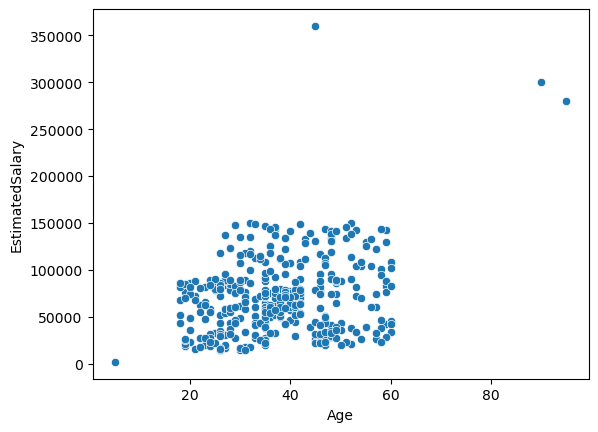

In [211]:
sns.scatterplot(x=df['Age'], y=df['EstimatedSalary'])

In [212]:
#  Splitting the data into train and test one
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, :-1], df.iloc[:, -1], test_size=0.3, random_state=0)

X_train.shape, X_test.shape

((282, 2), (122, 2))

In [213]:
from sklearn.preprocessing import StandardScaler

In [214]:
scaler = StandardScaler() 

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)   

# convert numpy arrays into pandas dataframe
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

<Axes: title={'center': 'After Scaling'}, xlabel='Age', ylabel='EstimatedSalary'>

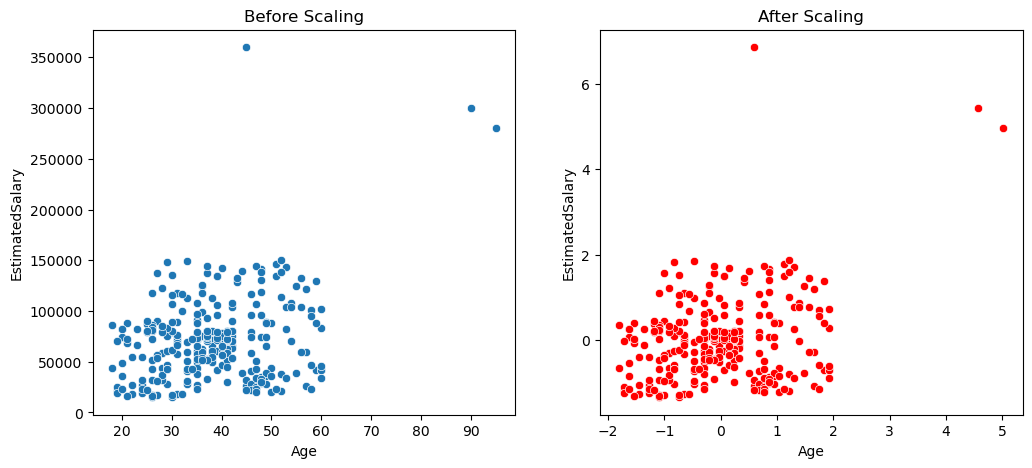

In [218]:
pyplot.figure(figsize=(12,5))
pyplot.subplot(1,2,1)
pyplot.title("Before Scaling")
sns.scatterplot(x=X_train['Age'], y=X_train['EstimatedSalary'])

pyplot.subplot(1,2,2)
pyplot.title("After Scaling")
sns.scatterplot(x=X_train_scaled['Age'], y=X_train_scaled['EstimatedSalary'], color='red')     
# one data [5, 2000] went to X_test         

#  as we can see even after scaling the impact of outlier has not reduced, we have to handle outliers explicitly.

<h2> When scaling REALLY matters :</h2>

In [220]:
# Algorithm Scaling needed?

# Logistic Regression	        ⚠️ Sometimes
# KNN	                        ✅ Mandatory
# SVM	                        ✅ Mandatory
# K-Means                       ✅ Mandatory
# Decision Tree	                ❌ Not needed
# Random Forest	                ❌ Not needed
# Gradient Boosting             ❌ Not needed
# XGBoost                       ❌ Not needed

<div align='center'>
    <img src='when-to-use-standardization.png', width='750'>
</div>